Firstly, let's import every package we will need in this analysis. It is required to install 
```Python
%pip install atlasopenmagic
```
in order to open ATLAS Open Data

In [95]:
import numpy as np
from numpy.lib.recfunctions import structured_to_unstructured   # to transform awk to linear numpy array
import pandas as pd                 
import uproot                       # to open .root files
import awkward as ak                # to read data with uproot
import matplotlib.pyplot as plt     # to plot
import vector                       # allows to manipulate Lorentz vectors
import os                           # to manage directories
import random                       # extract random numbers
import requests                     # for HTTP access
import aiohttp                      # HTTP client support
import atlasopenmagic as atom       # to access ATLAS Open Data directly
import seaborn as sns

from lmfit.models import PolynomialModel, GaussianModel
from matplotlib.ticker import AutoMinorLocator, MaxNLocator
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, roc_auc_score, auc, confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks


#tf.keras.mixed_precision.set_global_policy('mixed_float16')

## Import Data
Now we can download the dataset, selecting the release of interest. It is possible to see every release using
```Python
atom.available_releases()
```
We will use the 2025 release of data taken at $\sqrt{s}=13$ TeV in p-p collisions


In [96]:
atom.set_release("2025e-13tev-beta")    # select release
skim = "GamGam"                         # select skim: events with 2 photons
random.seed(24)                         # set seed for random extractions

# get keys for every dataset: Run2 datas have key="data", MC simulations have key=numbers
all_keys = atom.available_datasets()

run_url_list = atom.get_urls("data", skim, protocol="https", cache=True)      # get list of urls for Run2 data

# get list of urls for MC simulations
mc_url_list = []
for key in all_keys:
    if key != "data":
        mc_url_list += atom.get_urls(key, skim, protocol="https", cache=True)


print(f"Number of MonteCarlo simulated datasets: {len(mc_url_list)}")
print(f"Number of Run2 datasets: {len(run_url_list)}")

Release '2025e-13tev-beta' already active with cached metadata.
Active release: 2025e-13tev-beta. (Datasets path: REMOTE)


Number of MonteCarlo simulated datasets: 373
Number of Run2 datasets: 16


MC simulated datasets are produced considering only one process in each dataset. To select signal datasets we have to select urls that contain the Higgs boson decay channel of interest: into two photons.
Its notation in *gamgam*, *yy* or *_gammagamma*.

For background, we only select relevant processes: $\gamma\gamma$ from QCD continuum and $\gamma$+jet

In [97]:
# select signal datasets: may contain "gamgam" or "yy"
signal_url_list = [url for url in mc_url_list if ("gamgam" in url) or ("_gammagamma" in url) or ("Hyy" in url) or (("_yy" in url) and ("yyy" not in url))]

# select background datasets: all dataset not taken in signal
#bkg_url_list = [url for url in mc_url_list if url not in signal_url_list]
# continuous QCD diphoton background (Sherpa, 364350-364354)
diphoton_bkg_list = [url for url in mc_url_list if "Diphoton_myy" in url and (("90" in url) or ("175" in url))]

# gamma+jet (Pythia8, 423099-423112) background, without slice pT 8-17 GeV
gammajet_bkg_list = [url for url in mc_url_list if ("gammajet_DP" in url) and (("70" in url) or ("140" in url) or ("280" in url))]

# other background processes (ttgamma, )
other_processes = ["23LO_ttgamma", 
                   "eegamma", "eeggammagamma", "mumugamma", "mumugammagamma", "tautaugamma", "tautaugammagamma",    # charged leptons
                   "enugamma", "munugamma", "taunugamma", "nunugamma",                                              # neutrinos
                   "gamma2jets", "gammajj", "qqgamma", "bbgamma"]
other_bkg_list = [url for url in mc_url_list if any(process in url for process in other_processes)]

bkg_url_list = diphoton_bkg_list + gammajet_bkg_list + other_bkg_list

print("Number of diphoton background datasets: ", len(diphoton_bkg_list))
print("Number of gammajet background datasets: ", len(gammajet_bkg_list))
print("Number of Background datasets: ", len(bkg_url_list))
print("Number of Signal datasets: ", len(signal_url_list))

Number of diphoton background datasets:  3
Number of gammajet background datasets:  4
Number of Background datasets:  29
Number of Signal datasets:  25


In signal datasets we have some repeated processes: only one dataset for process is needed

In [98]:
# only one dataset for Higgs channel production
nominal_dsids = {
    "ggF":  "343981",
    "VBF":  "346214",
    "WmH":  "345317",
    "WpH":  "345318",
    "ZH":   "345319",
    "ggZH": "345061",
    "ttH":  "346525",
    "tHjb": "346188",
    "tWH":  "346486",
}

signal_nominal_list = [url for url in signal_url_list
                        if any(f"_mc_{dsid}." in url for dsid in nominal_dsids.values())]

print(f"Signal datasets (nominal): {len(signal_nominal_list)} / {len(signal_url_list)}")

Signal datasets (nominal): 9 / 25


Explore content of datasets: TTree and TBranches

In [99]:
# See names of trees and branches
print("Tree name: ", uproot.open(mc_url_list[0]).keys())
print("Branches: ", uproot.open(f"{mc_url_list[0]}:analysis").keys())

Tree name:  ['analysis;1']
Branches:  ['sig_ph', 'n_sig_ph', 'num_events', 'sum_of_weights', 'sum_of_weights_squared', 'xsec', 'kfac', 'filteff', 'TriggerMatch_DILEPTON', 'ScaleFactor_MLTRIGGER', 'ScaleFactor_PILEUP', 'ScaleFactor_FTAG', 'mcWeight', 'channelNumber', 'eventNumber', 'runNumber', 'trigML', 'trigP', 'trigDT', 'trigT', 'trigE', 'trigDM', 'trigDE', 'trigM', 'trigMET', 'ScaleFactor_BTAG', 'ScaleFactor_JVT', 'jet_n', 'jet_pt', 'jet_eta', 'jet_phi', 'jet_e', 'jet_btag_quantile', 'jet_jvt', 'largeRJet_n', 'largeRJet_pt', 'largeRJet_eta', 'largeRJet_phi', 'largeRJet_e', 'largeRJet_m', 'largeRJet_D2', 'jet_pt_jer1', 'jet_pt_jer2', 'ScaleFactor_ELE', 'ScaleFactor_MUON', 'ScaleFactor_LepTRIGGER', 'ScaleFactor_MuTRIGGER', 'ScaleFactor_ElTRIGGER', 'lep_n', 'lep_type', 'lep_pt', 'lep_eta', 'lep_phi', 'lep_e', 'lep_charge', 'lep_ptvarcone30', 'lep_topoetcone20', 'lep_z0', 'lep_d0', 'lep_d0sig', 'lep_isTightID', 'lep_isMediumID', 'lep_isLooseID', 'lep_isTightIso', 'lep_isLooseIso', 'lep_

Define TTree name and TBranches that we want to extract for this analysis

In [100]:
tree = "analysis"           # name of TTree in ATLAS OD

# features of the photons
features_ph = [branch for branch in (uproot.open(f"{mc_url_list[0]}:{tree}").keys()) 
            if ("photon_" in branch) and ("truth" not in branch)]
# variables of simulation
features_mc = ["channelNumber", "xsec", "kfac", "filteff", "mcWeight", "sum_of_weights", 'sum_of_weights_squared']

# total features we want to save
features = features_ph + features_mc

# luminosity
lumi = 36.1*1000            #pb-1 (36.1 fb-1)


Read datasets into awkward arrays. This procedure avoids errors in calling CERN server and it is the faster solution.
Then, label=1 is assigned to signal events, label=0 is assigned to background events.

Then, it is possible to save locally the awkward arrays and import them rapidly, without download

In [101]:
# boolean to read datasets from urls
download_ds = True

if download_ds:
    # read signal datasets into awkward array
    signal_array = []
    signal_head = []
    for url in signal_nominal_list:    
        with uproot.open(f"{url}:{tree}", timeout=60) as tree_opened:
            arr = tree_opened.arrays(filter_name=features, library="ak")
            signal_array.append(arr)
            signal_head.append(arr[0:1])
    signal_awk = ak.concatenate(signal_array)
    signal_ds = ak.concatenate(signal_head)         # 1 representative for dataset

    # assign label 1 to signal
    signal_awk["label"] = 1


    # read background datasets into awkward array
    bkg_array = []
    bkg_head = []
    for url in bkg_url_list:
        with uproot.open(f"{url}:{tree}", timeout=60) as tree_opened:
            arr = tree_opened.arrays(filter_name=features, library="ak")
            bkg_array.append(arr)
            bkg_head.append(arr[0:1])
    bkg_awk = ak.concatenate(bkg_array)
    bkg_ds = ak.concatenate(bkg_head)                # 1 representative for dataset

    # assign label 0 to background
    bkg_awk["label"] = 0            


    # merge signal and background arrays into one
    mc_awk = ak.concatenate([signal_awk, bkg_awk])
    mc_ds = ak.concatenate([signal_ds, bkg_ds])


    # create directory if needed and save array locally
    os.makedirs("data", exist_ok=True)
    ak.to_parquet(mc_awk, "data/mc_awkward_complete.parquet") 
    ak.to_parquet(mc_ds, "data/mc_ds.parquet")
    print("MC awkward array correctly saved!")

MC awkward array correctly saved!


In [7]:
# recover mc awkward arrays from local memory
mc_awk = ak.from_parquet("data/mc_awkward_complete.parquet")
mc_ds = ak.from_parquet("data/mc_ds.parquet")

print("MC awkward array correctly recovered!")

MC awkward array correctly recovered!


# Preprocessing Dataset
Now that we have the complete dataset, we need to preprocess for the Neural Network input.

Firstly, for each event, we order photons for decreasing $p_T$ in order to select the **leading** (index 0) and **subleading** (index 1) photons. These are the photons of interest for this analysis.

To do so, we need to separate *jagged* variables, that are associated to each photon, from *scalar* variables, that refers to the entire event. But first we have to select only photons that are well reconstructed and isolated. So, firstly we impose that leading and subleading photons respect the 2 strongest boolean conditions in the dataset.

In [102]:
# define function that sorts photons by pT: we will also use it for run2 dataset
def select_and_sort_photons_pt(array):
    # separate jagged and scalar var
    jagged_var = [var for var in array.fields if ("photon_" in var) and ("photon_n" not in var)]
    scalar_var = [var for var in array.fields if var not in jagged_var]

    # make mask for those conditions
    mask = (array.photon_isTightID & array.photon_isTightIso)

    # select photons, only work with jagged variables
    selected = {var: array[var][mask] for var in jagged_var}

    # select only events with more than 2 photons
    n_photons_mask = ak.num(selected["photon_pt"], axis=-1) >= 2
    selected = {var: selected[var][n_photons_mask] for var in jagged_var}
    
    # find indces of ordered photon, from higher pT to lower pT
    sorted_index = ak.argsort(selected["photon_pt"], axis=-1, ascending=False)
    
    # sort mc array with dictionary unpacking
    return ak.Array({
        **{var: selected[var][sorted_index] for var in jagged_var},
        **{var: array[var][n_photons_mask] for var in scalar_var},
    })

In [103]:
# sort MC array
mc_sort = select_and_sort_photons_pt(mc_awk)


In [104]:

# check that photons have been ordered
n_events_notord = len(mc_sort[mc_sort["photon_pt",:,0]<mc_sort["photon_pt",:,1]])
if n_events_notord == 0:
    print("Every event has been properly sorted by pT!")
else:
    print(f"Error: there are {n_events_notord} events that are not sorted")

Every event has been properly sorted by pT!


### Invariant Mass $m_{\gamma\gamma}$
Now it is useful to calculate the invariant mass of leading and subleading photons for each event. In natural units, the invariant mass is defined as
$$ m_{\gamma\gamma} = \sqrt{E^2_\text{tot}-(\vec{p}_\text{tot})^2} $$
We can calculate it using `.M` methon in `vector` library, using 4-momentum-like vectors defined as 
$$ p_4 = (E, p_T, \phi, \eta) $$
The result is given in GeV

In [105]:
# define a function to calculate invariant mass
def invariant_mass_calc(array):
    # build 4-momentum for each photon
    p4 = vector.zip({
        "pt": array.photon_pt,
        "eta": array.photon_eta,
        "phi": array.photon_phi,
        "e": array.photon_e
    })
    return (p4[:, 0] + p4[:, 1]).M

In [106]:
# add invariant mass column in MC awkward array 
mc_sort["photon_invariant_mass"] = invariant_mass_calc(mc_sort)

# limits for invariant mass
mass_inflimit = 100     # GeV
mass_suplimit = 160     # GeV

# select range of invariant mass
mc_filtered = mc_sort[(mc_sort["photon_invariant_mass"] > mass_inflimit) & (mc_sort["photon_invariant_mass"] < mass_suplimit)]

### Event weight
It is important to take into acccount the weight of the event. We can calculate it as
$$
w_{ev} = \frac{\sigma\cdot \mathcal{L} \cdot k \cdot \varepsilon_{filter} \cdot w_{mc,ev}}{\sum_{events}w_{mc}}
$$
and add it as a column of awkward array

In [107]:
# add event weight
mc_filtered["event_weight"] = mc_filtered["xsec"] * lumi * mc_filtered["kfac"] * mc_filtered["filteff"] * mc_filtered["mcWeight"] / mc_filtered["sum_of_weights"]

Shuffle events, given that we added them ordered

In [108]:
shuffled_idx = np.random.permutation(len(mc_filtered))
# get shuffled array
mc_final = mc_filtered[shuffled_idx]

### Features Extraction
Now that we have everything we need, let's proceed to extract features with some precautions.

- $p_T$: in order to avoid the NN to learn $m_{\gamma\gamma}$ dependence, we normalize $p_T$ for it
- $E_\gamma$: same procedure
- $\eta$: is already adimensional and $m_{\gamma\gamma}$-independent
- $\phi$: to avoid differences of $-\pi$ and $+\pi$, we transform it into two features: $\cos\phi$ and $\sin\phi$
- ptcone20: for same reasons as $p_T$, normalize wrt $p_T$ to get relative isolation
- topoetcone40: same as previous

In [109]:
# define a function that separates features for leading and subleading photon
def get_features(array):
    """
    Input: awkward array, that is the filtered dataset
    Output: one awkward array containing features for leading (l) and for subleading (s) photons, properly normalized
    """
    # get leading photon features
    lead_features = {
        "pt_l": array.photon_pt[:, 0] / array.photon_invariant_mass,
        "eta_l": array.photon_eta[:, 0],
        "phi_l": array.photon_phi[:, 0],
        "ptcone20_l": array.photon_ptcone20[:, 0] / array.photon_pt[:, 0],
        "topoetcone40_l": array.photon_topoetcone40[:, 0] / array.photon_pt[:, 0]
    }

    # get subleading photon features
    sublead_features = {
            "pt_s": array.photon_pt[:, 1] / array.photon_invariant_mass,
            "eta_s": array.photon_eta[:, 1],
            "phi_s": array.photon_phi[:, 1],
            "ptcone20_s": array.photon_ptcone20[:, 1] / array.photon_pt[:, 1],
            "topoetcone40_s": array.photon_topoetcone40[:, 1] / array.photon_pt[:, 1]
    }

    # merge dictionaries and transform into awkward arrays
    return ak.Array({**lead_features, **sublead_features})

In [110]:
# obtain features for MC dataset
mc_X_tot= get_features(mc_final)


Now that we have obtained all the features we need for leading and subleading photons, we want to split the dataset into *training dataset* and *test dataset*.

Then, some features have to be standardized before training, in order to keep their values centered in zero. Note that $\sin\phi$ and $\cos\phi$ doesn't need to be standardized. This procedure consists of the following transformation:
$$ \hat{x} = \frac{x-\mu}{\sigma} $$
where $\mu$ and $\sigma$ are the mean and the standard deviation of the **TRAIN** dataset of the feature $x$.

This is important: in order to train properly the NN, the transformation have to be the same during training and during test.


In [111]:
def get_train_test_datasets(array):
    """
    Gets the filtered dataset as awkward array, separates features for leading and subleading
    photon and normalizes them properly, using get_features function. Then, splits dataset into train and test
    and returns linearized (numpy) arrays of, respectively, features and labels for training and features and labels for test
    """

    # use previously defined function
    X_array = get_features(array)

    n_events = len(X_array)               # get number of events  
    indices = np.arange(n_events)         # get array of indices
    # split dataset, get arrays of indeces for train and test datasets
    train_idx, test_idx = train_test_split(indices, test_size=0.2, random_state=24)

    # arrays for training
    X_train = X_array[train_idx]        # features
    y_train = ak.to_numpy(array["label", train_idx])      # labels, to_numpy per linearizzare

    # arrays for test
    X_test = X_array[test_idx]          # features
    y_test = ak.to_numpy(array["label", test_idx])          # labels

    # select features to standardize
    features_to_scale = X_train.fields

    # calcuate mean and std dev on train dataset, for features we want to standardize, and construct two dictionaries
    means = {feature: ak.mean(X_train[feature]) for feature in features_to_scale}
    std_devs = {feature: ak.std(X_train[feature]) for feature in features_to_scale}
    
    
    # scale features
    X_train_scaled_struct = ak.to_numpy(ak.Array({
        **{feature: (X_train[feature] - means[feature]) / std_devs[feature] for feature in features_to_scale},
    }))
    X_test_scaled_struct = ak.to_numpy(ak.Array({
            **{feature: (X_test[feature] - means[feature]) / std_devs[feature] for feature in features_to_scale},
    }))

    X_train_scaled = structured_to_unstructured(X_train_scaled_struct).astype(np.float32)
    X_test_scaled = structured_to_unstructured(X_test_scaled_struct).astype(np.float32)

    # get weights
    w_train = ak.to_numpy(array.event_weight[train_idx]).astype(np.float32)
    w_test = ak.to_numpy(array.event_weight[test_idx]).astype(np.float32)
    
    mass_test = ak.to_numpy(array["photon_invariant_mass", test_idx]).astype(np.float32)

    return X_train_scaled, y_train, X_test_scaled, y_test, w_train, w_test, means, std_devs, mass_test

In [125]:
X_train, y_train, X_test , y_test, w_train, w_test, means, std_devs, mass_test  = get_train_test_datasets(mc_final)


Now the dataset is ready!

We can now resume the preprocessing steps in a single funtion that includes all preprocessing functions

In [42]:
def build_dataset(array, means=None, std_devs=None):
    """
    Important! Explicit means and std_dev only if dataset is run data! They have to be those used during training


    Resume function to preprocess dataset:
    1) Sorts photons by pT and filters dataset from events whose photons are not well reconstructed or not well isolated
    2) Calculates invariant mass of leading and subleading photon, for each event
    3) Selects proper range of invariant mass
    4) Add event weight
    5) Shuffle elements of array
    6) Separates features for leading and subleading photon, then normalizes them properly
    7) Standardizes features that need it

    If the dataset is a MC simulation, returns 6 arrays and that are X_train, y_train, X_test, y_test, means, std_devs
    If the dataset is Run data, returns 2 arrays: X (features of two photons, whitout training/test split), array_final (dataset)
    """

    # check if dataset is simulation or run data
    is_mc = "label" in array.fields

    # 1) Sort photons by pT and filters dataset from events whose photons are not well reconstructed or not well isolated
    array_sorted = select_and_sort_photons_pt(array)

    # 2) Calculates invariant mass of leading and subleading photon, for each event
    array_sorted["photon_invariant_mass"] = invariant_mass_calc(array_sorted)

    # 3) Selects proper range of invariant mass
    # limits for invariant mass
    mass_inflimit = 100     # GeV
    mass_suplimit = 160     # GeV

    # select range of invariant mass
    array_filtered = array_sorted[(array_sorted["photon_invariant_mass"] > mass_inflimit) & (array_sorted["photon_invariant_mass"] < mass_suplimit)]

    # 4) Add event weight
    array_filtered["event_weight"] = array_filtered["xsec"] * lumi * array_filtered["kfac"] * array_filtered["filteff"] * array_filtered["mcWeight"] / array_filtered["sum_of_weights"]

    # 5) Shuffle elements of array
    shuffled_idx = np.random.permutation(len(array_filtered))
    # get shuffled array
    array_final = array_filtered[shuffled_idx]

    # 6) Separates features for leading and subleading photon, then normalizes them properly
    # 7) Standardizes features that need it

    if is_mc:
        return get_train_test_datasets(array_final)
    else:               # if is Run data, we need mean and std_devs from the train dataset, to normalize
        if (means==None) and (std_devs==None):
            raise ValueError("Means and Standard Deviations are not specified for Run dataset! Specify them")
        else:
            X = get_features(array_final)

            # standardize features with training mean and std dev values
            X_scaled_struct = ak.to_numpy(ak.Array({
                            **{feature: (X[feature] - means[feature]) / std_devs[feature] for feature in X.fields},
                    }))
            X_scaled = structured_to_unstructured(X_scaled_struct).astype(np.float32)

            mass_run = ak.to_numpy(array_final.photon_invariant_mass).astype(np.float32)
            return X_scaled, array_final, mass_run


In [123]:
# get arrays for training and test
X_train, y_train, X_test , y_test, w_train, w_test, means, std_devs, mass_test = build_dataset(mc_awk)

### Feature preview

In [126]:
# invariant mass plot
def plot_invariant_mass(array, weight=None):
    f_myy, ax_myy = plt.subplots(1, 1, figsize=(8,5))
    ax_myy.hist(array["photon_invariant_mass"], weights=weight, bins=70, histtype="step")
    ax_myy.set_xlabel(r"$m_{\gamma\gamma}$ [GeV]")
    ax_myy.set_ylabel("Entries")
    ax_myy.set_title(r"Diphoton invariant mass $m_{\gamma\gamma}$ spectrum")


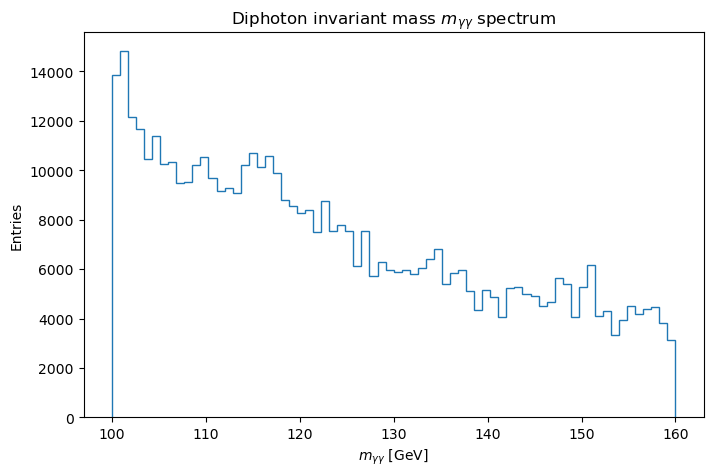

In [127]:
# invariant mass spectrum for MC data
plot_invariant_mass(mc_final, mc_final.event_weight)

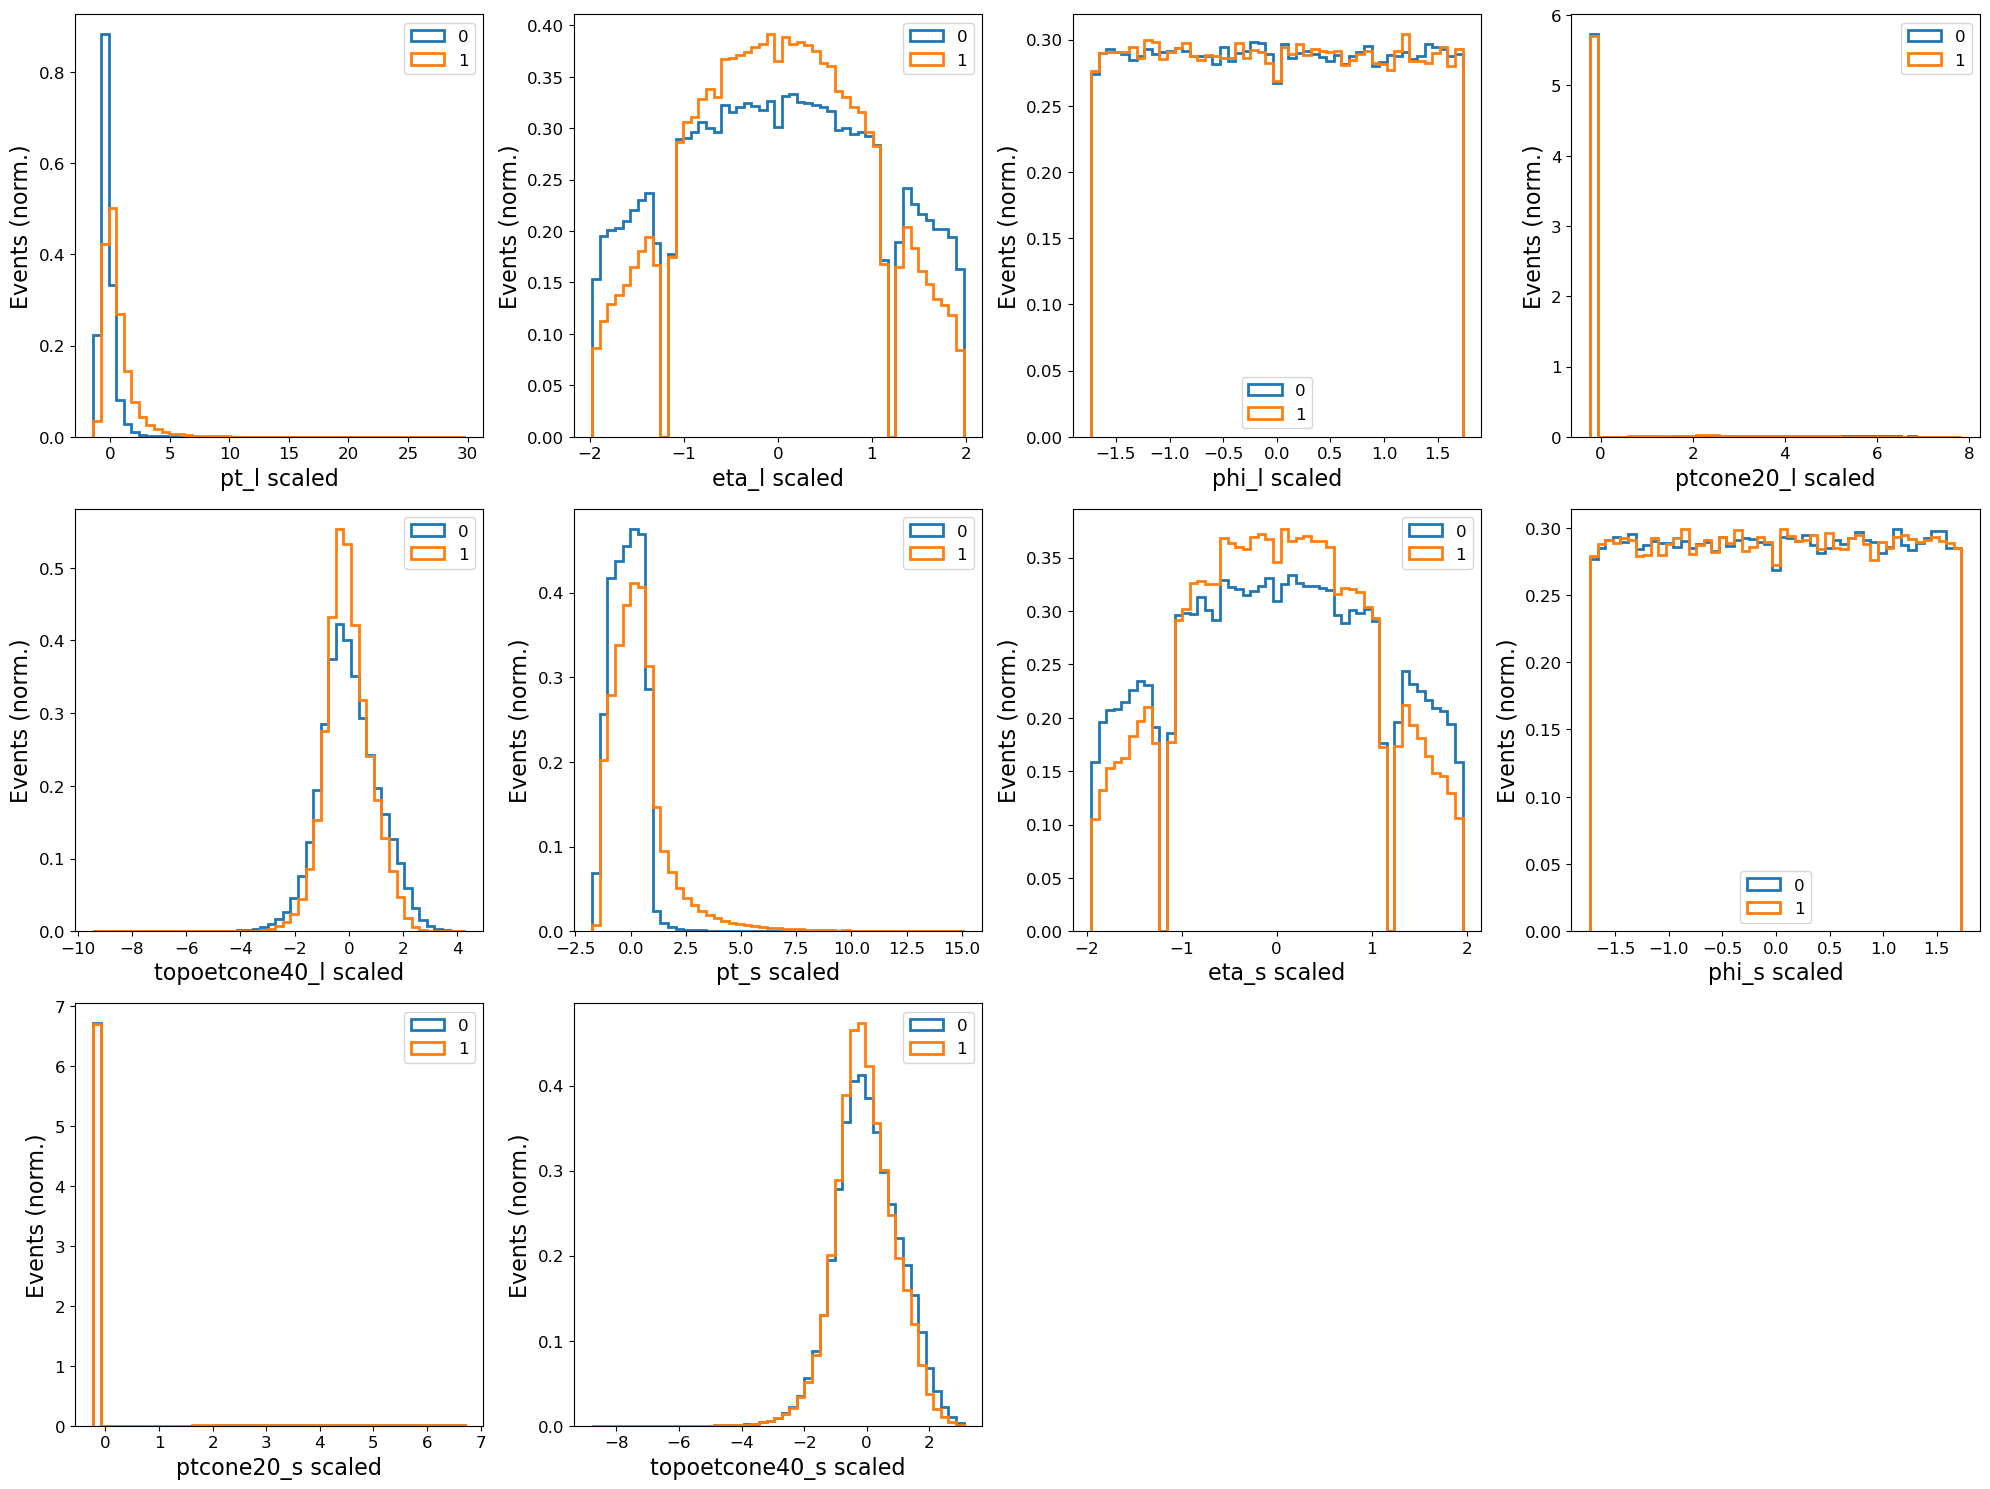

In [148]:
#take all the features name
feature_names = list(means.keys()) 

n_feat = len(feature_names)
categories = np.unique(y_train)

n_cols = 4
n_rows = int(np.ceil(n_feat / n_cols))

fig, axs = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 5 * n_rows))
axs = axs.reshape(-1)

for ix, ax in enumerate(axs):
    if ix >= n_feat:
        ax.axis("off")   # hide the empty subplots
        continue

    feat = feature_names[ix]
    col = X_train[:, ix]  

    bins = np.linspace(np.min(col), np.max(col), 50)

    for c in categories:
        mask = (y_train == c)
        ax.hist(col[mask], bins=bins, histtype="step",
                 density=True, label=str(c), lw=2)

    ax.set_xlabel(feat+" scaled", fontsize=16)
    ax.set_ylabel("Events (norm.)", fontsize=16)
    ax.tick_params(axis="both", which="major", labelsize=12)
    ax.legend(fontsize=12, loc="best")

plt.tight_layout()
plt.show()

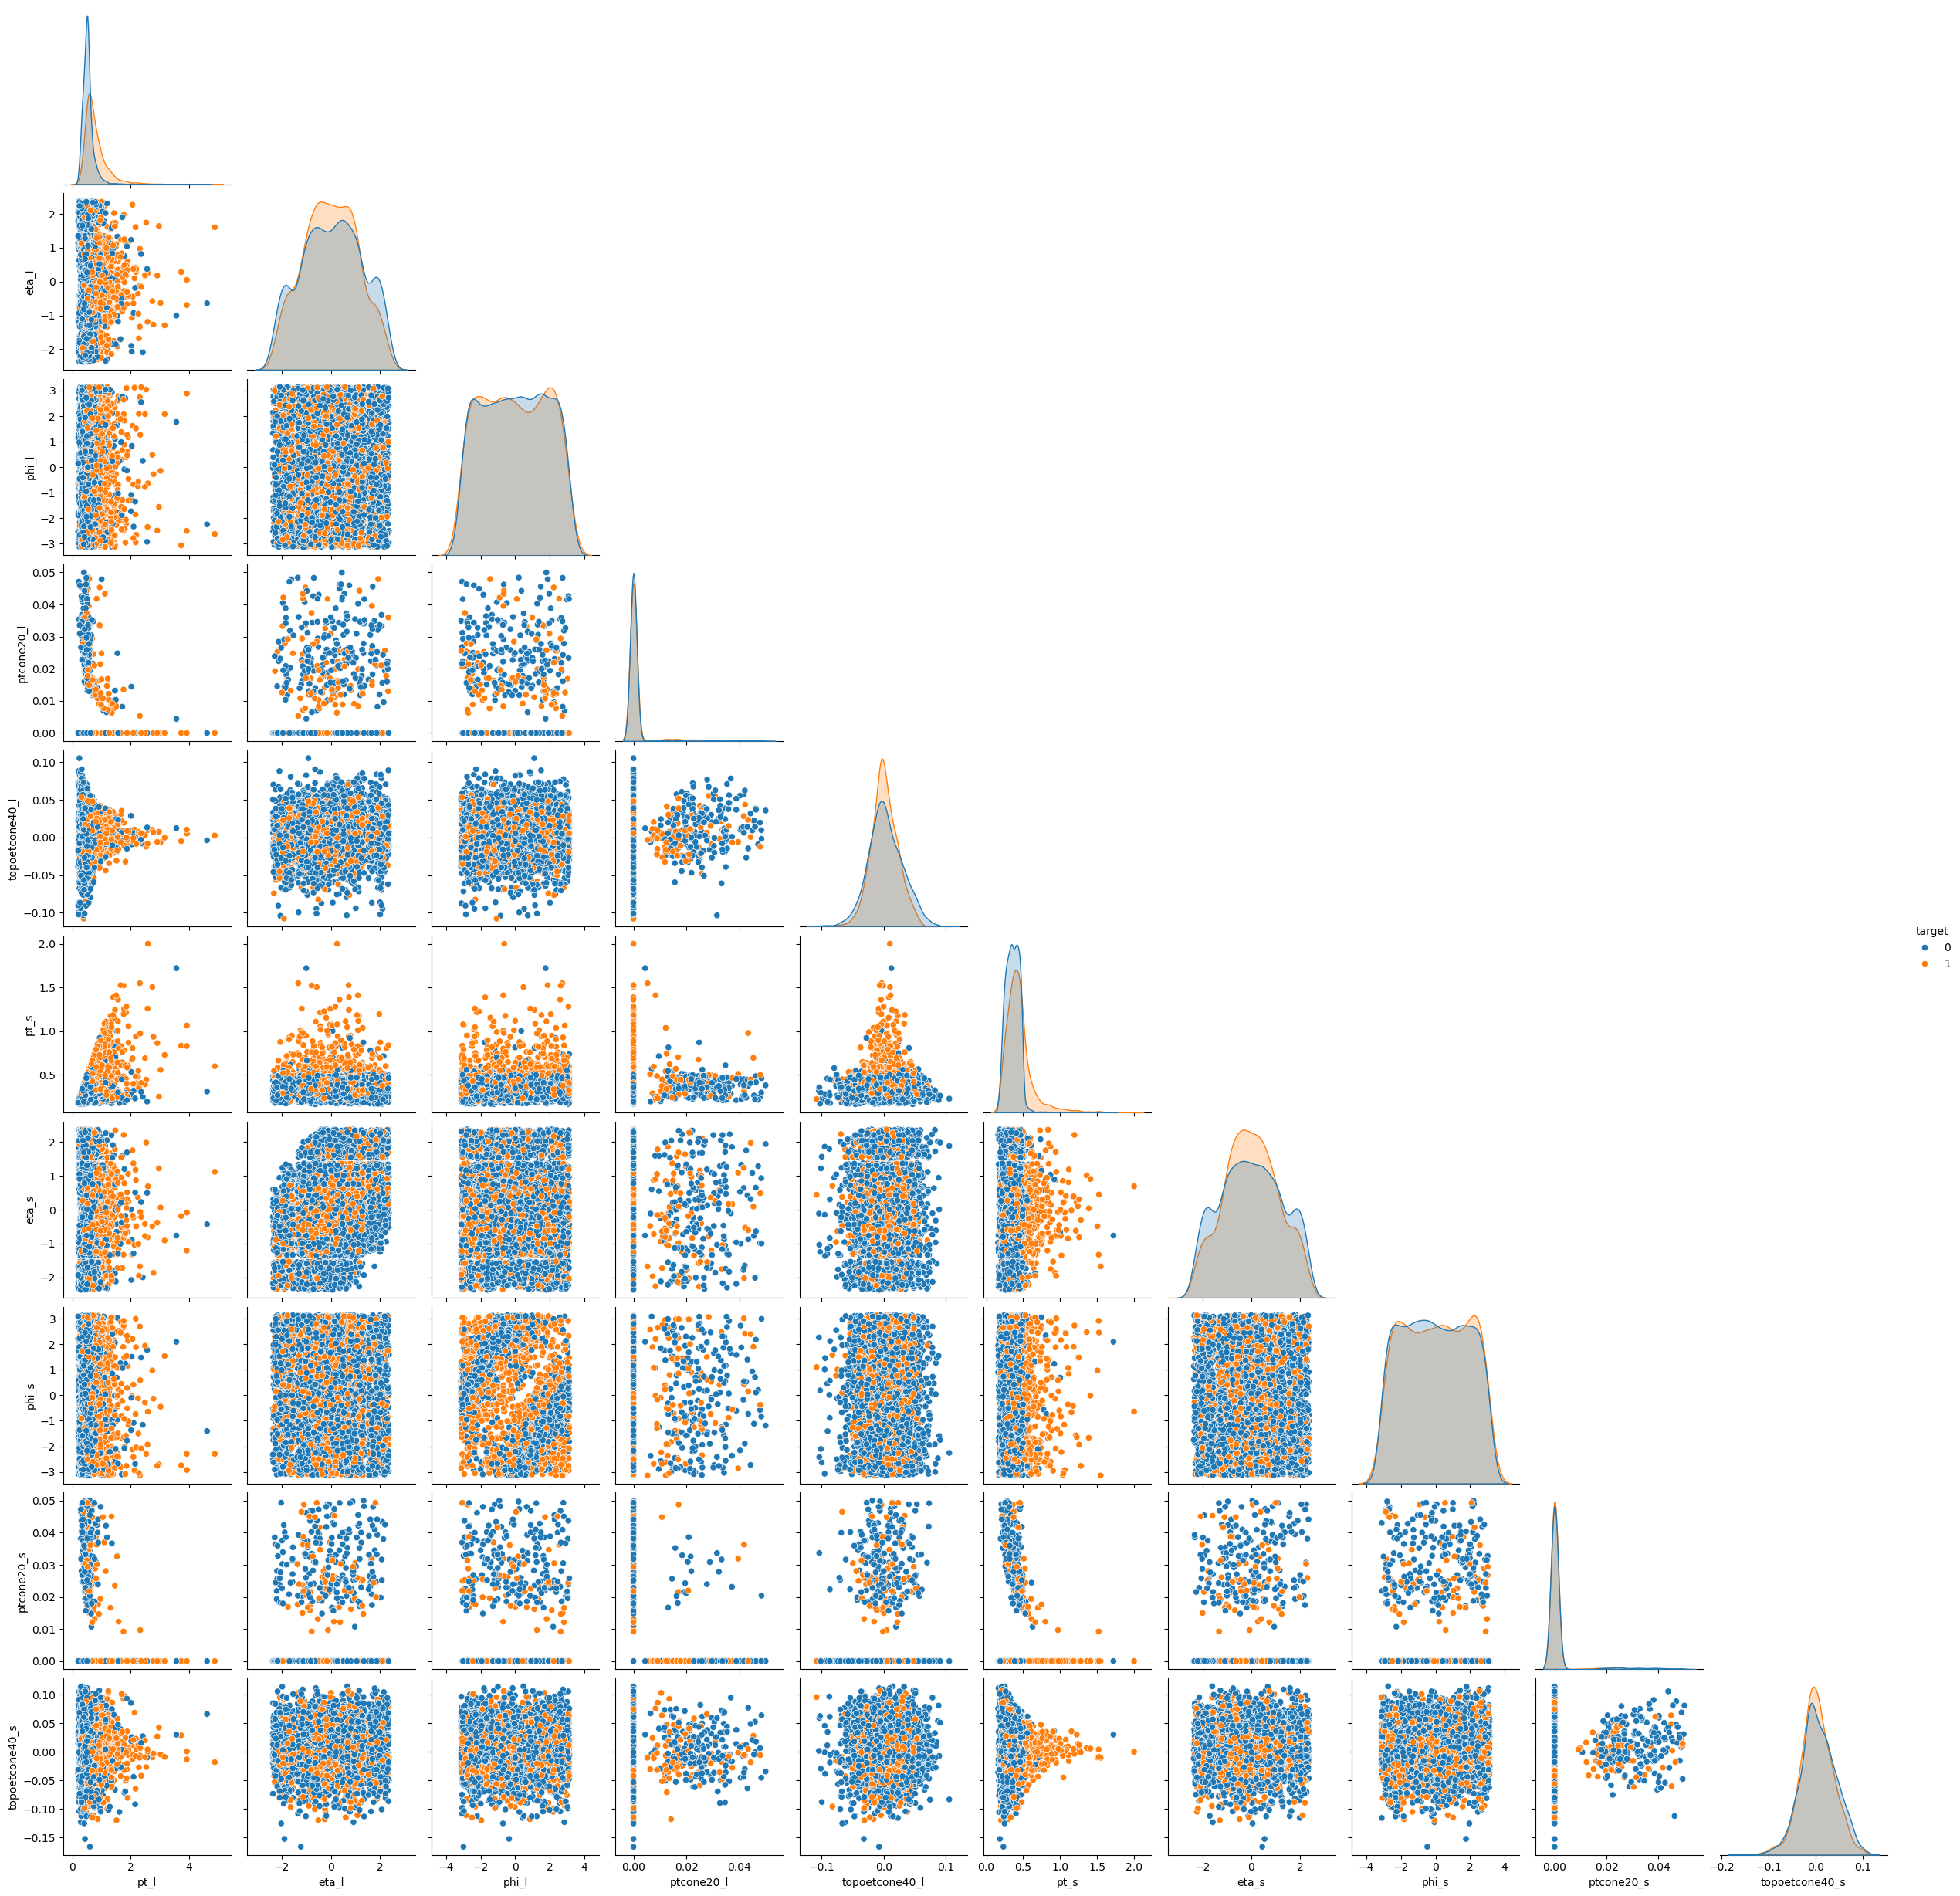

In [149]:
df = ak.to_dataframe(mc_X_tot)
df["target"] = ak.to_numpy(mc_final.label)
df["target"] = df["target"].astype("category")

sns.pairplot(df.sample(5000, random_state=42), hue="target", vars=feature_names, corner=True, diag_kind="kde", diag_kws={"common_norm": False})
plt.show()

# Building Neural Network

### Neural Network Architecture (Baseline)

This network is a classic **Multilayer Perceptron (MLP)** or *feed-forward* network, designed for a **binary classification** hence we use a single output neuron with a *Sigmoid* activation and the *binary_crossentropy* loss function.

#### Network Schematic

```text
[ Input Layer ] 
      │
      ▼
┌──────────────────────────────────────────────┐
│ HIDDEN BLOCK 1                               │
│ 1. Dense Layer (32 neurons, ReLU)            │
│ 2. Batch Normalization                       │
│ 3. Dropout (30% deactivated)                 │
└──────────────────────────────────────────────┘
      │
      ▼
┌──────────────────────────────────────────────┐
│ HIDDEN BLOCK 2                               │
│ 1. Dense Layer (16 neurons, ReLU)            │
│ 2. Batch Normalization                       │
│ 3. Dropout (40% deactivated)                 │
└──────────────────────────────────────────────┘
      │
      ▼
[ Output Layer ] (1 neuron, Sigmoid) ──> Outputs a probability (0,1)

In [167]:
# Neural Network architecture

def build_baseline_nn(input_dim):
    """Creates a simple neural network, fully-connected and regularized"""

    model = models.Sequential([
        layers.Input(shape=(input_dim,)),

        layers.Dense(32, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.2),

        layers.Dense(32, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        layers.Dense(16, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        
        layers.Dense(1, activation="sigmoid")
    ])
    
    model.compile(
        optimizer=optimizers.Adam(learning_rate=0.001),
        loss="binary_crossentropy",
        weighted_metrics=[tf.keras.metrics.AUC(name="auc"), "accuracy"]
    )
    return model

Train set shape: (718984, 10)
Test set shape: (179747, 10)
Model: "sequential_15"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_50 (Dense)            (None, 32)                352       
                                                                 
 batch_normalization_35 (Ba  (None, 32)                128       
 tchNormalization)                                               
                                                                 
 dropout_35 (Dropout)        (None, 32)                0         
                                                                 
 dense_51 (Dense)            (None, 32)                1056      
                                                                 
 batch_normalization_36 (Ba  (None, 32)                128       
 tchNormalization)                                               
                                                            

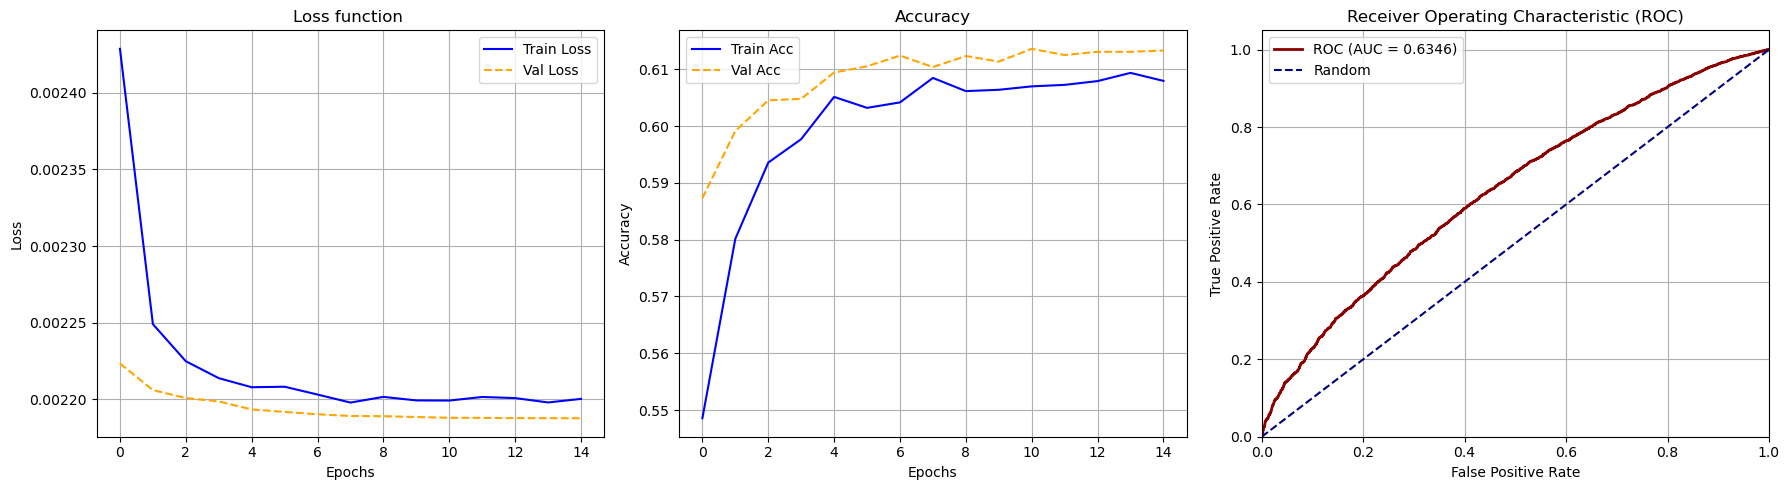

In [168]:
# Pipeline execution

# hyperparameters settings
epochs = 15
batch_size = 1024
validation_split = 0.15
emphasis = 1

prediction_threshold = 0.5

# balance weights: weights of background are way bigger than signal ones
w_train_balanced = w_train.copy()
w_train_balanced[y_train == 0] *= (w_train[y_train == 1].sum() / w_train[y_train == 0].sum()) / emphasis

# absolute value of weights: with Binary Cross Entropy negative weights maximise Loss
w_train_abs = np.abs(w_train_balanced)


# variable learning rate
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

# early stopping
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)



if __name__ == "__main__":
        
    print(f"Train set shape: {X_train.shape}")
    print(f"Test set shape: {X_test.shape}")
    
    event_dim, features_dim = X_train.shape
    
    model = build_baseline_nn(input_dim=features_dim)
    model.summary()
    
    print("\nBegin training...")
    history = model.fit(
        X_train, y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_split=validation_split,
        verbose=1,
        sample_weight=w_train_abs,
        callbacks=[reduce_lr, early_stopping]
    )
    



    print("\nPerformance evaluation on Test set...")
    # batch_size specified in order to avoid memory peaks during prediction
    y_pred_prob = model.predict(X_test, batch_size=batch_size).ravel()
    y_pred = (y_pred_prob > prediction_threshold).astype(int)
    
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    # Performance plots
    fig, (ax_loss, ax_acc, ax_roc) = plt.subplots(1, 3, figsize=(18, 5))
    
    # 1. Loss plot
    ax_loss.plot(history.history["loss"], label="Train Loss", color="blue")
    ax_loss.plot(history.history["val_loss"], label="Val Loss", color="orange", linestyle="--")
    ax_loss.set_title("Loss function ")
    ax_loss.set_xlabel("Epochs")
    ax_loss.set_ylabel("Loss")
    ax_loss.legend()
    ax_loss.grid(True)
    
    # 2. Accuracy Plot
    ax_acc.plot(history.history["accuracy"], label="Train Acc", color="blue")
    ax_acc.plot(history.history["val_accuracy"], label="Val Acc", color="orange", linestyle="--")
    ax_acc.set_title("Accuracy")
    ax_acc.set_xlabel("Epochs")
    ax_acc.set_ylabel("Accuracy")
    ax_acc.legend()
    ax_acc.grid(True)
    
    # 3. ROC & AUC plot
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob, sample_weight=w_test)

    # roc_auc score, weighted
    # IT IS NOT MONOTONE, SO WE USE TRAPZ
    roc_auc = np.trapz(tpr, fpr)
    
    ax_roc.plot(fpr, tpr, color="darkred", lw=2, label=f"ROC (AUC = {roc_auc:.4f})")
    ax_roc.plot(np.array((0, 1)), np.array((0, 1)), color="navy", linestyle="--", label="Random")
    ax_roc.set_xlim(np.array((0.0, 1.0)))
    ax_roc.set_ylim(np.array((0.0, 1.05)))
    ax_roc.set_xlabel("False Positive Rate")
    ax_roc.set_ylabel("True Positive Rate")
    ax_roc.set_title("Receiver Operating Characteristic (ROC)")
    ax_roc.legend()
    ax_roc.grid(True)
    
    plt.tight_layout()
    plt.show()
    plt.close('all')

## Invariant Mass Plot
Let's compare the invariant mass plot before and after the discriminator, with Run2 data.

In [136]:
# import Run2 data
run_array = []
for url in run_url_list[0:2]: 
    with uproot.open(f"{url}:{tree}", timeout=60) as tree_opened:
        arr = tree_opened.arrays(filter_name=features, library="ak")
        run_array.append(arr)
run_awk = ak.concatenate(run_array)

# create directory if needed and save array locally
os.makedirs("data", exist_ok=True)
ak.to_parquet(run_awk, "data/run_awk.parquet") 
print("Run awkward array correctly saved!")

Run awkward array correctly saved!


In [160]:
# recover mc awkward arrays from local memory
run_awk = ak.from_parquet("data/run_awk.parquet")

print("Run awkward array correctly recovered!")

# preprocess dataset
run_X, run_final, mass_run = build_dataset(run_awk, means, std_devs)

Run awkward array correctly recovered!


Prediction of signal events in Run2 data

In [169]:
y_pred_prob_run = model.predict(run_X, batch_size=batch_size).ravel()
y_pred_run = (y_pred_prob_run > prediction_threshold).astype(int)

6/6 [==============================] - 0s 3ms/step


Comparation of invariant mass spectrum before and after classification, using ad-hoc function

In [162]:
def invariant_mass_plots(mass, y_pred_prob, prediction_treshold, weights=None):
    """
    Function that compares invariant mass spectrum before and after the classification
    """
    binning = 60
    signal_mask = y_pred_prob > prediction_threshold

    # ------------------------------------------------------------------
    # Select "signal" data after NN cut
    # ------------------------------------------------------------------
    selected_mass = mass[signal_mask]
    if weights is not None:
        selected_weights = weights[signal_mask]
    else: selected_weights = None

    fig, ax = plt.subplots(1, 1, figsize=(8,5))
    ax.hist(mass, weights=weights, bins=binning,
           histtype="step", label="Pre-selection NN (S+B)", color="gray")
    ax.hist(selected_mass, bins=binning, weights=selected_weights,
                    histtype="step", label="Post-selection NN (S)", color="darkred")

    ax.set_xlabel(r"$m_{\gamma\gamma}$ [GeV]")
    ax.set_ylabel("Entries")
    ax.set_title(r"Diphoton invariant mass $m_{\gamma\gamma}$ spectrum")
    ax.legend()
    plt.show()


    # ------------------------------------------------------------------
    # Binning
    # ------------------------------------------------------------------
    xmin, xmax = 100, 160     # same limits used for the invariant mass cut
    step_size = 1                 # GeV per bin, adjust according to your statistics

    bin_edges = np.arange(start=xmin, stop=xmax + step_size, step=step_size)
    bin_centres = (bin_edges[:-1] + bin_edges[1:]) / 2

    # ------------------------------------------------------------------
    # Histogram of the data (weighted, since we have event_weight)
    # ------------------------------------------------------------------
    data_x, _ = np.histogram(selected_mass, bins=bin_edges, weights=selected_weights)
    # weighted statistical error: sqrt(sum(w^2)) per bin, more correct than sqrt(N) when weights are not uniform
    if selected_weights is not None:
        data_x_errors2, _ = np.histogram(selected_mass, bins=bin_edges, weights=selected_weights**2)
    else:
        data_x_errors2, _ = np.histogram(selected_mass, bins=bin_edges)         # ** not supported for None type
    data_x_errors = np.sqrt(data_x_errors2)
    # avoid division by zero in empty bins
    data_x_errors[data_x_errors == 0] = 1e-6

    # ------------------------------------------------------------------
    # Fit: background (4th order polynomial) + signal (gaussian)
    # ------------------------------------------------------------------
    polynomial_mod = PolynomialModel(4)
    gaussian_mod = GaussianModel()

    pars = polynomial_mod.guess(data_x, x=bin_centres, c0=data_x.max(), c1=0, c2=0, c3=0, c4=0)
    pars += gaussian_mod.guess(data_x, x=bin_centres, amplitude=100, center=125, sigma=2)

    total_function = polynomial_mod + gaussian_mod

    out = total_function.fit(data_x, pars, x=bin_centres, weights=1/data_x_errors)

    # ------------------------------------------------------------------
    # Extract background component from the fit
    # ------------------------------------------------------------------
    params_dict = out.params.valuesdict()
    c0 = params_dict['c0']
    c1 = params_dict['c1']
    c2 = params_dict['c2']
    c3 = params_dict['c3']
    c4 = params_dict['c4']

    background = c0 + c1*bin_centres + c2*bin_centres**2 + c3*bin_centres**3 + c4*bin_centres**4

    # signal = data - background
    signal_x = data_x - background

    # ------------------------------------------------------------------
    # Main plot
    # ------------------------------------------------------------------
    fig = plt.figure(figsize=(8, 8))

    plt.axes([0.1, 0.3, 0.85, 0.65])
    main_axes = plt.gca()

    main_axes.errorbar(x=bin_centres, y=data_x, yerr=data_x_errors,
                        fmt='ko', label='NN selection (signal)', markersize=4)

    main_axes.plot(bin_centres, out.best_fit, '-r',
                    label='Sig+Bkg Fit ($m_H=125$ GeV)')

    main_axes.plot(bin_centres, background, '--r',
                    label='Bkg (4th order polynomial)')

    # vertical dashed red line at 125 GeV (expected Higgs mass peak)
    main_axes.axvline(x=125, color='red', linestyle=':', linewidth=1.5,
                       label=r'$m_H=125$ GeV')

    main_axes.set_xlim(left=xmin, right=xmax)
    main_axes.xaxis.set_minor_locator(AutoMinorLocator())

    main_axes.tick_params(which='both', direction='in', top=True,
                           labelbottom=False, right=True)

    main_axes.set_ylabel('Events / ' + str(step_size) + ' GeV',
                          horizontalalignment='right')

    main_axes.set_ylim(bottom=0, top=np.amax(data_x)*1.5)
    main_axes.yaxis.set_minor_locator(AutoMinorLocator())
    main_axes.yaxis.get_major_ticks()[0].set_visible(False)

    plt.text(0.8, 0.9, r'$H \rightarrow \gamma\gamma$', transform=main_axes.transAxes)

    main_axes.legend(frameon=False, loc='lower left')

    # ------------------------------------------------------------------
    # Sub plot: Data - Background
    # ------------------------------------------------------------------
    plt.axes([0.1, 0.1, 0.85, 0.2])
    sub_axes = plt.gca()

    sub_axes.yaxis.set_major_locator(MaxNLocator(nbins='auto', symmetric=True))

    sub_axes.errorbar(x=bin_centres, y=signal_x, yerr=data_x_errors,
                       fmt='ko', markersize=4)

    sub_axes.plot(bin_centres, out.best_fit - background, '-r')
    sub_axes.plot(bin_centres, background - background, '--r')

    # vertical dashed red line at 125 GeV, also in the residuals sub-plot
    sub_axes.axvline(x=125, color='red', linestyle=':', linewidth=1.5)

    sub_axes.set_xlim(left=xmin, right=xmax)
    sub_axes.xaxis.set_minor_locator(AutoMinorLocator())

    sub_axes.set_xlabel(r'Di-photon invariant mass $\mathrm{m_{\gamma\gamma}}$ [GeV]',
                        x=1, horizontalalignment='right', fontsize=13)

    sub_axes.tick_params(which='both', direction='in', top=True, right=True)
    sub_axes.yaxis.set_minor_locator(AutoMinorLocator())
    sub_axes.set_ylabel('Events-Bkg')

    main_axes.yaxis.set_label_coords(-0.09, 1)
    sub_axes.yaxis.set_label_coords(-0.09, 0.5)

    plt.show()

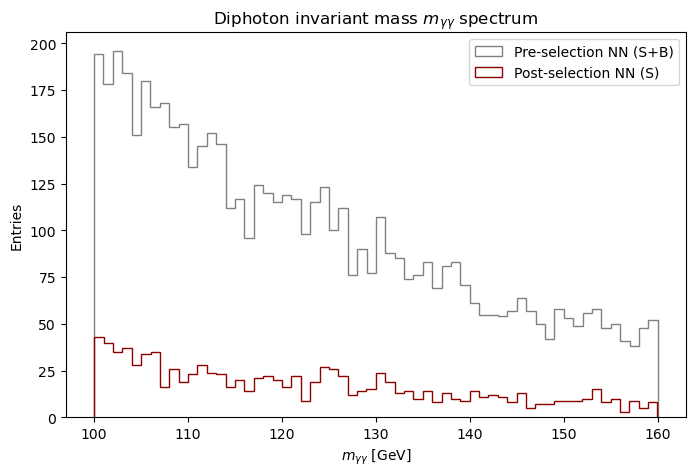

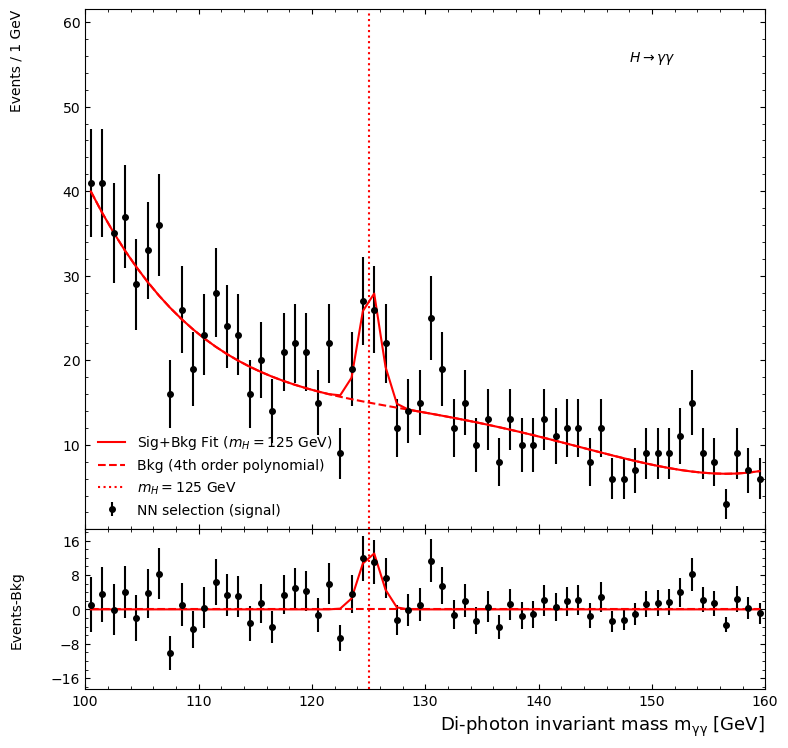

In [170]:
invariant_mass_plots(mass_run, y_pred_prob=y_pred_prob_run, prediction_treshold=prediction_threshold)